In [2]:
import os
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tushare as ts

from tqdm import tqdm
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

plt.rcParams["font.sans-serif"]=["SimHei","Microsoft YaHei","Arial Unicode MS"]
plt.rcParams["axes.unicode_minus"]=False

TOKEN = "2ef1ddd337f03798fbe36c340ba0afab6e31003f5998565ef0322c08"
ts.set_token(TOKEN)
pro=ts.pro_api()

DATA_START="20200101"
DATA_END="20251231"
SAMPLE_START="20210101"
SAMPLE_END="20251130"

SAVE_DIR="./price_path_project"
os.makedirs(SAVE_DIR,exist_ok=True)

# 获取全A股股票池并做初步筛选

In [3]:
stock_basic=pro.stock_basic(exchange="",list_status="L",fields="ts_code,symbol,name,area,industry,market,exchange,list_date")
stock_basic["list_date"]=pd.to_datetime(stock_basic["list_date"],errors="coerce")
stock_pool=stock_basic.copy()
stock_pool=stock_pool[stock_pool["ts_code"].str.endswith((".SH",".SZ"))].copy()

stock_pool=stock_pool[
    ~stock_pool["name"].str.contains("ST|退",regex=True,na=False)
].copy()

stock_pool=stock_pool[
    stock_pool["list_date"].notna()
].copy()

stock_pool=stock_pool.sort_values("ts_code").reset_index(drop=True)

print("原始A股数量:",len(stock_basic))
print("筛选后股票数量:",len(stock_pool))
print("交易所分布:")
print(stock_pool["exchange"].value_counts())
print("\n市场分布:")
print(stock_pool["market"].value_counts())
stock_pool.head()

原始A股数量: 5529
筛选后股票数量: 4970
交易所分布:
exchange
SZSE    2751
SSE     2219
Name: count, dtype: int64

市场分布:
market
主板     3022
创业板    1351
科创板     597
Name: count, dtype: int64


,ts_code,symbol,name,area,industry,market,exchange,list_date
0,000001.SZ,000001,平安银行,深圳,银行,主板,SZSE,1991-04-03
1,000002.SZ,000002,万科A,深圳,全国地产,主板,SZSE,1991-01-29
2,000006.SZ,000006,深振业A,深圳,区域地产,主板,SZSE,1992-04-27
3,000007.SZ,000007,全新好,深圳,其他商业,主板,SZSE,1992-04-13
4,000008.SZ,000008,神州高铁,北京,运输设备,主板,SZSE,1992-05-07


In [4]:
stock_pool.to_csv(f"{SAVE_DIR}/stock_pool.csv",index=False,encoding="utf-8-sig")
codes=stock_pool["ts_code"].tolist()
print("股票数量:",len(codes))
print(codes[:10])

股票数量: 4970
['000001.SZ', '000002.SZ', '000006.SZ', '000007.SZ', '000008.SZ', '000009.SZ', '000011.SZ', '000012.SZ', '000014.SZ', '000017.SZ']


备注：数据下载环节使用ai帮助 因为我想分段下载 要不然容易等很久还不显示
不知道是不是电脑的问题 日度下载极慢 遂使用月度数据

In [6]:
#月度
cal=pro.trade_cal(
    exchange="SSE",
    start_date=DATA_START,
    end_date=DATA_END,
    is_open="1",
    fields="cal_date,is_open"
)

cal["cal_date"]=pd.to_datetime(cal["cal_date"])
cal["month"]=cal["cal_date"].dt.to_period("M")

month_ends=cal.groupby("month")["cal_date"].max().reset_index()
month_ends["trade_date"]=month_ends["cal_date"].dt.strftime("%Y%m%d")

month_dates=month_ends["trade_date"].tolist()

price_file=f"{SAVE_DIR}/price_month_end.csv"
failed_dates=[]

if os.path.exists(price_file):
    price_month=pd.read_csv(price_file,dtype={"ts_code":str,"trade_date":str})
    done_dates=set(price_month["trade_date"].unique())
else:
    price_month=pd.DataFrame()
    done_dates=set()

todo_dates=[d for d in month_dates if d not in done_dates]

print("已完成月份:",len(done_dates))
print("待下载月份:",len(todo_dates))

data_list=[]

for d in tqdm(todo_dates):
    try:
        daily=pro.daily(
            trade_date=d,
            fields="ts_code,trade_date,open,high,low,close,vol,amount"
        )
        adj=pro.adj_factor(
            trade_date=d,
            fields="ts_code,trade_date,adj_factor"
        )
        df=daily.merge(adj,on=["ts_code","trade_date"],how="left")
        df=df[df["ts_code"].isin(codes)].copy()
        df["adj_close"]=df["close"]*df["adj_factor"]
        data_list.append(df)
        time.sleep(0.2)
    except Exception as e:
        failed_dates.append({"trade_date":d,"error":str(e)})

if len(data_list)>0:
    new_price=pd.concat(data_list,ignore_index=True)
    price_month=pd.concat([price_month,new_price],ignore_index=True)
    price_month=price_month.drop_duplicates(["ts_code","trade_date"])
    price_month.to_csv(price_file,index=False,encoding="utf-8-sig")

price_month=pd.read_csv(price_file,dtype={"ts_code":str,"trade_date":str})
price_month["trade_date"]=pd.to_datetime(price_month["trade_date"])

print("价格数据维度:",price_month.shape)
print("股票数量:",price_month["ts_code"].nunique())
print("时间范围:",price_month["trade_date"].min(),"-",price_month["trade_date"].max())
print("失败月份:",len(failed_dates))

price_month.head()

已完成月份: 72
待下载月份: 72


100%|██████████████████████████████████████████████████████████████████████████████████| 72/72 [00:47<00:00,  1.51it/s]


ValueError: time data "20200123" doesn't match format "%Y-%m-%d", at position 72. You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

In [ ]:
retry_dates=[x["trade_date"] for x in failed_dates]

new_data=[]

for d in tqdm(retry_dates):
    daily=pro.daily(
        trade_date=d,
        fields="ts_code,trade_date,open,high,low,close,vol,amount"
    )
    adj=pro.adj_factor(
        trade_date=d,
        fields="ts_code,trade_date,adj_factor"
    )
    df=daily.merge(adj,on=["ts_code","trade_date"],how="left")
    df=df[df["ts_code"].isin(codes)].copy()
    df["adj_close"]=df["close"]*df["adj_factor"]
    new_data.append(df)
    time.sleep(0.5)

if len(new_data)>0:
    add_price=pd.concat(new_data,ignore_index=True)
    price_month=pd.concat([price_month,add_price],ignore_index=True)
    price_month=price_month.drop_duplicates(["ts_code","trade_date"])
    price_month.to_csv(price_file,index=False,encoding="utf-8-sig")

print("补充后维度:",price_month.shape)
print("月份数量:",price_month["trade_date"].nunique())
print("时间范围:",price_month["trade_date"].min(),"-",price_month["trade_date"].max())

In [7]:
price_month["trade_date"]=pd.to_datetime(price_month["trade_date"],errors="coerce")

price_month=price_month.dropna(subset=["trade_date","ts_code","adj_close"])
price_month=price_month.drop_duplicates(["ts_code","trade_date"])
price_month=price_month.sort_values(["ts_code","trade_date"]).reset_index(drop=True)

price_month.to_csv(price_file,index=False,encoding="utf-8-sig")

print("价格数据维度:",price_month.shape)
print("股票数量:",price_month["ts_code"].nunique())
print("月份数量:",price_month["trade_date"].nunique())
print("时间范围:",price_month["trade_date"].min(),"-",price_month["trade_date"].max())

price_month.head()

价格数据维度: (313993, 10)
股票数量: 4934
月份数量: 72
时间范围: 2020-01-23 00:00:00 - 2025-12-31 00:00:00


,ts_code,trade_date,open,high,low,close,vol,amount,adj_factor,adj_close
0,000001.SZ,2020-01-23,15.92,15.92,15.39,15.54,1100592.07,1723394.336,109.1694,1696.492476
1,000001.SZ,2020-02-28,14.85,15.04,14.46,14.50,1300644.45,1906892.413,109.1694,1582.956300
2,000001.SZ,2020-03-31,13.05,13.09,12.78,12.80,513370.30,662915.471,109.1694,1397.368320
3,000001.SZ,2020-04-30,14.02,14.32,13.88,13.93,819540.43,1155968.238,109.1694,1520.729742
4,000001.SZ,2020-05-29,13.01,13.04,12.92,13.00,457808.22,594502.123,111.0487,1443.633100


月度收益率和下一月收益率

In [8]:
price_panel=price_month.copy()
price_panel=price_panel.merge(
    stock_pool[["ts_code","name","industry","market","exchange","list_date"]],
    on="ts_code",
    how="left"
)

price_panel=price_panel.sort_values(["ts_code","trade_date"]).reset_index(drop=True)
price_panel["ret"]=price_panel.groupby("ts_code")["adj_close"].pct_change()
price_panel["ret_lead1m"]=price_panel.groupby("ts_code")["ret"].shift(-1)

price_panel["list_months"]=(price_panel["trade_date"]-price_panel["list_date"]).dt.days/30

print("ret非缺失:",price_panel["ret"].notna().sum())
print("ret_lead1m非缺失:",price_panel["ret_lead1m"].notna().sum())

price_panel[["ts_code","trade_date","name","adj_close","ret","ret_lead1m","list_months"]].head(10)

ret非缺失: 309059
ret_lead1m非缺失: 309059


,ts_code,trade_date,name,adj_close,ret,ret_lead1m,list_months
0,000001.SZ,2020-01-23,平安银行,1696.492476,NaN,-0.066924,350.733333
1,000001.SZ,2020-02-28,平安银行,1582.956300,-0.066924,-0.117241,351.933333
2,000001.SZ,2020-03-31,平安银行,1397.368320,-0.117241,0.088281,353.000000
3,000001.SZ,2020-04-30,平安银行,1520.729742,0.088281,-0.050697,354.000000
4,000001.SZ,2020-05-29,平安银行,1443.633100,-0.050697,-0.015385,354.966667
5,000001.SZ,2020-06-30,平安银行,1421.423360,-0.015385,0.042187,356.033333
6,000001.SZ,2020-07-31,平安银行,1481.389658,0.042187,0.130435,357.066667
7,000001.SZ,2020-08-31,平安银行,1674.614396,0.130435,0.005968,358.100000
8,000001.SZ,2020-09-30,平安银行,1684.608779,0.005968,0.170073,359.100000
9,000001.SZ,2020-10-30,平安银行,1971.114425,0.170073,0.112113,360.100000


样本筛选：2021年1月至2025年11月、上市满12个月、收益率和下一月收益率不缺失的样本。

In [9]:
sample=price_panel.copy()

sample=sample[(sample["trade_date"]>=pd.to_datetime(SAMPLE_START))&(sample["trade_date"]<=pd.to_datetime(SAMPLE_END))].copy()

sample=sample[(sample["list_months"]>=12)&(sample["ret"].notna())&(sample["ret_lead1m"].notna())].copy()

sample=sample.sort_values(["ts_code","trade_date"]).reset_index(drop=True)

print("正式样本维度:",sample.shape)
print("股票数量:",sample["ts_code"].nunique())
print("月份数量:",sample["trade_date"].nunique())
print("时间范围:",sample["trade_date"].min(),"-",sample["trade_date"].max())

month_count=sample.groupby("trade_date")["ts_code"].nunique()
print("\n每月股票数量:")
print(month_count.describe())

sample[["ts_code","trade_date","name","market","industry","adj_close","ret","ret_lead1m","list_months"]].head()

正式样本维度: (250738, 18)
股票数量: 4836
月份数量: 59
时间范围: 2021-01-29 00:00:00 - 2025-11-28 00:00:00

每月股票数量:
count      59.00000
mean     4249.79661
std       488.59908
min      3340.00000
25%      3834.00000
50%      4341.00000
75%      4724.00000
max      4821.00000
Name: ts_code, dtype: float64


,ts_code,trade_date,name,market,industry,adj_close,ret,ret_lead1m,list_months
0,000001.SZ,2021-01-29,平安银行,主板,银行,2564.12141,0.193902,-0.074058,363.133333
1,000001.SZ,2021-02-26,平安银行,主板,银行,2374.22762,-0.074058,0.029467,364.066667
2,000001.SZ,2021-03-31,平安银行,主板,银行,2444.18849,0.029467,0.058155,365.166667
3,000001.SZ,2021-04-30,平安银行,主板,银行,2586.33121,0.058155,0.047241,366.166667
4,000001.SZ,2021-05-31,平安银行,主板,银行,2708.51240,0.047241,-0.065289,367.200000


In [10]:
factor_panel=price_panel.copy()
factor_panel=factor_panel.sort_values(["ts_code","trade_date"]).reset_index(drop=True)

factor_panel["reversal_1m"]=-factor_panel["ret"]
factor_panel["momentum_12m"]=factor_panel.groupby("ts_code")["ret"].transform(lambda x:(1+x).rolling(12).apply(np.prod,raw=True)-1)
factor_panel["volatility_12m"]=factor_panel.groupby("ts_code")["ret"].transform(lambda x:x.rolling(12).std())

factor_sample=factor_panel[
    (factor_panel["trade_date"]>=pd.to_datetime(SAMPLE_START))&
    (factor_panel["trade_date"]<=pd.to_datetime(SAMPLE_END))&
    (factor_panel["list_months"]>=12)&
    (factor_panel["ret_lead1m"].notna())
].copy()

print("传统因子样本维度:",factor_sample.shape)
print("月份数量:",factor_sample["trade_date"].nunique())
print("股票数量:",factor_sample["ts_code"].nunique())

factor_sample[["ts_code","trade_date","name","ret","ret_lead1m","reversal_1m","momentum_12m","volatility_12m"]].head(15)

传统因子样本维度: (250738, 21)
月份数量: 59
股票数量: 4836


,ts_code,trade_date,name,ret,ret_lead1m,reversal_1m,momentum_12m,volatility_12m
12,000001.SZ,2021-01-29,平安银行,0.193902,-0.074058,-0.193902,0.511425,0.099341
13,000001.SZ,2021-02-26,平安银行,-0.074058,0.029467,0.074058,0.499869,0.100054
14,000001.SZ,2021-03-31,平安银行,0.029467,0.058155,-0.029467,0.749137,0.087423
15,000001.SZ,2021-04-30,平安银行,0.058155,0.047241,-0.058155,0.700717,0.086684
16,000001.SZ,2021-05-31,平安银行,0.047241,-0.065289,-0.047241,0.876178,0.080915
17,000001.SZ,2021-06-30,平安银行,-0.065289,-0.217949,0.065289,0.781085,0.086072
18,000001.SZ,2021-07-30,平安银行,-0.217949,0.006218,0.217949,0.336515,0.116341
19,000001.SZ,2021-08-31,平安银行,0.006218,0.007303,-0.006218,0.189654,0.112121
20,000001.SZ,2021-09-30,平安银行,0.007303,0.087563,-0.007303,0.191233,0.112106
21,000001.SZ,2021-10-29,平安银行,0.087563,-0.105641,-0.087563,0.107231,0.104366


In [11]:
def factor_test(data,factor):
    df=data[["trade_date","ts_code",factor,"ret_lead1m"]].dropna().copy()
    
    df["q"]=df.groupby("trade_date")[factor].transform(lambda x:pd.qcut(x.rank(method="first"),5,labels=["Q1","Q2","Q3","Q4","Q5"]))
    group_ret=df.groupby(["trade_date","q"])["ret_lead1m"].mean().reset_index()
    group_pivot=group_ret.pivot(index="trade_date",columns="q",values="ret_lead1m")
    group_pivot["Q5-Q1"]=group_pivot["Q5"]-group_pivot["Q1"]
    
    ic=df.groupby("trade_date").apply(lambda x:x[factor].rank().corr(x["ret_lead1m"].rank()))
    
    result={
        "factor":factor,
        "Q1_mean":group_pivot["Q1"].mean(),
        "Q5_mean":group_pivot["Q5"].mean(),
        "Q5_Q1_mean":group_pivot["Q5-Q1"].mean(),
        "Q5_Q1_std":group_pivot["Q5-Q1"].std(),
        "Q5_Q1_pos_ratio":(group_pivot["Q5-Q1"]>0).mean(),
        "RankIC_mean":ic.mean(),
        "RankIC_std":ic.std(),
        "RankIC_pos_ratio":(ic>0).mean(),
        "month_num":ic.shape[0]
    }
    
    return result,group_pivot,ic

reversal_result,reversal_group_ret,reversal_ic=factor_test(factor_sample,"reversal_1m")#短期反转因子
momentum_result,momentum_group_ret,momentum_ic=factor_test(factor_sample,"momentum_12m")#中期动量因子
volatility_result,volatility_group_ret,volatility_ic=factor_test(factor_sample,"volatility_12m")#波动率因子

factor_result=pd.DataFrame([reversal_result,momentum_result,volatility_result])
factor_result["factor_name"]=["短期反转","中期动量","波动率"]

factor_result=factor_result[["factor_name","factor","Q1_mean","Q5_mean","Q5_Q1_mean","Q5_Q1_std","Q5_Q1_pos_ratio","RankIC_mean","RankIC_std","RankIC_pos_ratio","month_num"]]
factor_result_pct=factor_result.copy()

pct_cols=["Q1_mean","Q5_mean","Q5_Q1_mean","Q5_Q1_std","Q5_Q1_pos_ratio","RankIC_mean","RankIC_std","RankIC_pos_ratio"]
factor_result_pct[pct_cols]=factor_result_pct[pct_cols]*100
factor_result_pct

,factor_name,factor,Q1_mean,Q5_mean,Q5_Q1_mean,Q5_Q1_std,Q5_Q1_pos_ratio,RankIC_mean,RankIC_std,RankIC_pos_ratio,month_num
0,短期反转,reversal_1m,0.510976,1.431041,0.920065,4.112849,54.237288,6.120503,13.608244,66.101695,59
1,中期动量,momentum_12m,1.419130,0.553504,-0.865626,4.342966,42.372881,-6.044880,14.352025,33.898305,59
2,波动率,volatility_12m,1.473605,0.904215,-0.569390,5.071883,42.372881,-6.797113,17.589698,37.288136,59


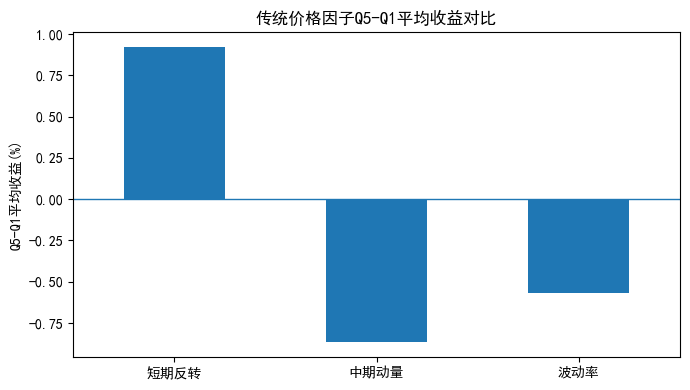

In [12]:
factor_result_pct.to_csv(f"{SAVE_DIR}/traditional_factor_result.csv",index=False,encoding="utf-8-sig")
plot_df=factor_result_pct.set_index("factor_name")["Q5_Q1_mean"]

plt.figure(figsize=(7,4))
plot_df.plot(kind="bar")
plt.axhline(0,linewidth=1)
plt.title("传统价格因子Q5-Q1平均收益对比")
plt.ylabel("Q5-Q1平均收益(%)")
plt.xlabel("")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/traditional_factor_q5q1.png",dpi=300)
plt.show()

构造12个月标准化价格路径

In [13]:
path_data=price_panel.copy()
path_data=path_data.sort_values(["ts_code","trade_date"]).reset_index(drop=True)
base=path_data.groupby("ts_code")["adj_close"].shift(11)
for k in range(12):
    path_data[f"path_{k}"]=path_data.groupby("ts_code")["adj_close"].shift(11-k)/base
path_cols=[f"path_{k}" for k in range(12)]

path_sample=path_data[
    (path_data["trade_date"]>=pd.to_datetime(SAMPLE_START))&
    (path_data["trade_date"]<=pd.to_datetime(SAMPLE_END))&
    (path_data["list_months"]>=12)&
    (path_data["ret_lead1m"].notna())
].copy()

path_sample=path_sample.dropna(subset=path_cols+["ret_lead1m"])
path_sample=path_sample.sort_values(["ts_code","trade_date"]).reset_index(drop=True)
path_sample.to_csv(f"{SAVE_DIR}/path_sample.csv",index=False,encoding="utf-8-sig")

print("路径样本维度:",path_sample.shape)
print("股票数量:",path_sample["ts_code"].nunique())
print("月份数量:",path_sample["trade_date"].nunique())
print("时间范围:",path_sample["trade_date"].min(),"-",path_sample["trade_date"].max())

path_sample[["ts_code","trade_date","name"]+path_cols+["ret_lead1m"]].head()

路径样本维度: (250690, 30)
股票数量: 4836
月份数量: 59
时间范围: 2021-01-29 00:00:00 - 2025-11-28 00:00:00


,ts_code,trade_date,name,path_0,path_1,path_2,path_3,path_4,path_5,path_6,path_7,path_8,path_9,path_10,path_11,ret_lead1m
0,000001.SZ,2021-01-29,平安银行,1.0,0.882759,0.960690,0.911985,0.897955,0.935837,1.057903,1.064217,1.245211,1.384815,1.356754,1.619831,-0.074058
1,000001.SZ,2021-02-26,平安银行,1.0,1.088281,1.033109,1.017215,1.060128,1.198406,1.205558,1.410590,1.568736,1.536948,1.834965,1.699071,0.029467
2,000001.SZ,2021-03-31,平安银行,1.0,0.949303,0.934698,0.974131,1.101191,1.107763,1.296164,1.441480,1.412271,1.686112,1.561242,1.607247,0.058155
3,000001.SZ,2021-04-30,平安银行,1.0,0.984615,1.026154,1.160000,1.166923,1.365385,1.518462,1.487692,1.776159,1.644620,1.693081,1.791543,0.047241
4,000001.SZ,2021-05-31,平安银行,1.0,1.042187,1.178125,1.185156,1.386719,1.542188,1.510938,1.803911,1.670317,1.719536,1.819536,1.905493,-0.065289


0615新修改

In [14]:
#参考点变量构造
ref_sample = path_sample.copy()
past_path_cols = [f"path_{k}" for k in range(0, 11)]
current_path_col = "path_11"

#窗口起点参考点：当前价格相对12个月窗口起点的位置
ref_sample["ref_start_12"] = ref_sample["path_0"]
ref_sample["gap_start_12"] = ref_sample[current_path_col] / ref_sample["ref_start_12"] - 1

#等权历史参考点：过去12个月窗口内历史价格的平均参考位置
ref_sample["ref_ew_12"] = ref_sample[past_path_cols].mean(axis=1)
ref_sample["cgo_ew_12"] = ref_sample[current_path_col] / ref_sample["ref_ew_12"] - 1

#历史高点参考点：当前价格相对过去窗口内高点的位置
ref_sample["ref_high_12"] = ref_sample[past_path_cols].max(axis=1)
ref_sample["dist_high_12"] = ref_sample[current_path_col] / ref_sample["ref_high_12"] - 1

#路径波动特征：过去12个月标准化路径的波动程度
ref_sample["path_std_12"] = ref_sample[past_path_cols].std(axis=1)

check_cols = [
    "ts_code", "trade_date", "name", "path_0", "path_11",
    "gap_start_12", "ref_ew_12", "cgo_ew_12",
    "ref_high_12", "dist_high_12", "ret", "ret_lead1m"
]
print("参考点样本维度:", ref_sample.shape)
print("月份数量:", ref_sample["trade_date"].nunique())
print("股票数量:", ref_sample["ts_code"].nunique())

ref_sample[check_cols].head()

参考点样本维度: (250690, 37)
月份数量: 59
股票数量: 4836


,ts_code,trade_date,name,path_0,path_11,gap_start_12,ref_ew_12,cgo_ew_12,ref_high_12,dist_high_12,ret,ret_lead1m
0,000001.SZ,2021-01-29,平安银行,1.0,1.619831,0.619831,1.063466,0.523162,1.384815,0.169709,0.193902,-0.074058
1,000001.SZ,2021-02-26,平安银行,1.0,1.699071,0.699071,1.268540,0.339391,1.834965,-0.074058,-0.074058,0.029467
2,000001.SZ,2021-03-31,平安银行,1.0,1.607247,0.607247,1.224032,0.313076,1.686112,-0.046773,0.029467,0.058155
3,000001.SZ,2021-04-30,平安银行,1.0,1.791543,0.791543,1.347554,0.329478,1.776159,0.008662,0.058155,0.047241
4,000001.SZ,2021-05-31,平安银行,1.0,1.905493,0.905493,1.441692,0.321706,1.819536,0.047241,0.047241,-0.065289


In [15]:
#短期反转因子与全样本RankIC
ic_sample = ref_sample.copy()

#短期反转因子：当月收益取反
ic_sample["rev_1m"] = -ic_sample["ret"]
ic_sample = ic_sample.dropna(subset=["rev_1m", "ret_lead1m", "cgo_ew_12"])

def calc_rank_ic(data, factor_col, ret_col="ret_lead1m"):
    out = []
    for d, g in data.groupby("trade_date"):
        tmp = g[[factor_col, ret_col]].dropna()
        if len(tmp) < 30:
            continue
        
        ic = tmp[factor_col].corr(tmp[ret_col], method="spearman")
        out.append({
            "trade_date": d,
            "rank_ic": ic,
            "sample_count": len(tmp)
        })
    
    return pd.DataFrame(out)
rev_ic = calc_rank_ic(ic_sample, "rev_1m")
rev_ic_summary = pd.DataFrame({
    "factor": ["rev_1m"],
    "month_num": [rev_ic["trade_date"].nunique()],
    "ic_mean": [rev_ic["rank_ic"].mean()],
    "ic_std": [rev_ic["rank_ic"].std()],
    "icir": [rev_ic["rank_ic"].mean() / rev_ic["rank_ic"].std()],
    "ic_positive_ratio": [(rev_ic["rank_ic"] > 0).mean()],
    "avg_sample_count": [rev_ic["sample_count"].mean()]
})

rev_ic_summary

,factor,month_num,ic_mean,ic_std,icir,ic_positive_ratio,avg_sample_count
0,rev_1m,59,0.06117,0.136108,0.449424,0.661017,4248.983051


In [16]:
#参考点状态分组下的短期反转因子RankIC
group_ic_sample = ic_sample.copy()
#按每个月的cgo_ew_12分成三组：低CGO、中CGO、高CGO
def assign_cgo_group(x):
    try:
        return pd.qcut(
            x,
            q=3,
            labels=["低CGO组", "中CGO组", "高CGO组"]
        )
    except ValueError:
        return pd.Series([np.nan] * len(x), index=x.index)

group_ic_sample["cgo_group_3"] = group_ic_sample.groupby("trade_date")["cgo_ew_12"].transform(assign_cgo_group)
group_ic_sample = group_ic_sample.dropna(subset=["cgo_group_3", "rev_1m", "ret_lead1m"])
#计算每个月、每个CGO组内的短期反转RankIC
group_ic_list = []
for (d, gname), g in group_ic_sample.groupby(["trade_date", "cgo_group_3"]):
    tmp = g[["rev_1m", "ret_lead1m"]].dropna()
    
    if len(tmp) < 30:
        continue
    
    ic = tmp["rev_1m"].corr(tmp["ret_lead1m"], method="spearman")
    
    group_ic_list.append({
        "trade_date": d,
        "cgo_group": gname,
        "rank_ic": ic,
        "sample_count": len(tmp)
    })

cgo_group_ic = pd.DataFrame(group_ic_list)
#汇总各CGO组的IC表现
cgo_group_ic_summary = cgo_group_ic.groupby("cgo_group").agg(
    month_num=("trade_date", "nunique"),
    ic_mean=("rank_ic", "mean"),
    ic_std=("rank_ic", "std"),
    ic_positive_ratio=("rank_ic", lambda x: (x > 0).mean()),
    avg_sample_count=("sample_count", "mean")
).reset_index()

cgo_group_ic_summary["icir"] = cgo_group_ic_summary["ic_mean"] / cgo_group_ic_summary["ic_std"]
cgo_group_ic_summary = cgo_group_ic_summary[
    ["cgo_group", "month_num", "ic_mean", "ic_std", "icir", "ic_positive_ratio", "avg_sample_count"]
]

cgo_group_ic_summary

,cgo_group,month_num,ic_mean,ic_std,icir,ic_positive_ratio,avg_sample_count
0,中CGO组,59,0.030464,0.132971,0.229100,0.542373,1415.949153
1,低CGO组,59,0.007563,0.138909,0.054449,0.491525,1416.423729
2,高CGO组,59,0.076844,0.128751,0.596842,0.762712,1416.610169


In [17]:
# 不同参考点定义下的短期反转因子RankIC检验
robust_ic_sample = ic_sample.copy()
ref_var_dict = {"cgo_ew_12": "等权历史参考点", "gap_start_12": "窗口起点参考点", "dist_high_12": "历史高点参考点"}

def add_monthly_group(data, var_col, group_col):
    data[group_col] = data.groupby("trade_date")[var_col].transform(
        lambda x: pd.qcut(
            x.rank(method="first"),
            q=3,
            labels=["低参考点组", "中参考点组", "高参考点组"]
        )
    )
    return data

def calc_group_rank_ic(data, ref_col, ref_name):
    tmp_data = data.dropna(subset=[ref_col, "rev_1m", "ret_lead1m"]).copy()
    tmp_data = add_monthly_group(tmp_data, ref_col, "ref_group")
    ic_list = []
    
    for (d, gname), g in tmp_data.groupby(["trade_date", "ref_group"], observed=True):
        tmp = g[["rev_1m", "ret_lead1m"]].dropna()
        
        if len(tmp) < 30:
            continue
        
        ic = tmp["rev_1m"].corr(tmp["ret_lead1m"], method="spearman")
        ic_list.append({
            "ref_type": ref_name,
            "ref_var": ref_col,
            "trade_date": d,
            "ref_group": gname,
            "rank_ic": ic,
            "sample_count": len(tmp)
        })
    
    return pd.DataFrame(ic_list)
all_ref_ic = []

for ref_col, ref_name in ref_var_dict.items():
    tmp_ic = calc_group_rank_ic(robust_ic_sample, ref_col, ref_name)
    all_ref_ic.append(tmp_ic)
all_ref_ic = pd.concat(all_ref_ic, ignore_index=True)

ref_robust_summary = all_ref_ic.groupby(["ref_type", "ref_var", "ref_group"]).agg(
    month_num=("trade_date", "nunique"),
    ic_mean=("rank_ic", "mean"),
    ic_std=("rank_ic", "std"),
    ic_positive_ratio=("rank_ic", lambda x: (x > 0).mean()),
    avg_sample_count=("sample_count", "mean")
).reset_index()

ref_robust_summary["icir"] = ref_robust_summary["ic_mean"] / ref_robust_summary["ic_std"]
ref_robust_summary = ref_robust_summary[
    ["ref_type", "ref_var", "ref_group", "month_num", "ic_mean", "ic_std", "icir", "ic_positive_ratio", "avg_sample_count"]
]

ref_robust_summary

,ref_type,ref_var,ref_group,month_num,ic_mean,ic_std,icir,ic_positive_ratio,avg_sample_count
0,历史高点参考点,dist_high_12,中参考点组,59,0.023284,0.130056,0.179035,0.508475,1416.033898
1,历史高点参考点,dist_high_12,低参考点组,59,0.030293,0.135397,0.223733,0.593220,1416.322034
2,历史高点参考点,dist_high_12,高参考点组,59,0.094637,0.135907,0.696338,0.813559,1416.627119
3,窗口起点参考点,gap_start_12,中参考点组,59,0.050889,0.147238,0.345626,0.559322,1416.033898
4,窗口起点参考点,gap_start_12,低参考点组,59,0.025364,0.138022,0.183765,0.508475,1416.322034
5,窗口起点参考点,gap_start_12,高参考点组,59,0.082812,0.137225,0.603478,0.694915,1416.627119
6,等权历史参考点,cgo_ew_12,中参考点组,59,0.030506,0.132908,0.229524,0.542373,1416.033898
7,等权历史参考点,cgo_ew_12,低参考点组,59,0.007516,0.138967,0.054085,0.491525,1416.322034
8,等权历史参考点,cgo_ew_12,高参考点组,59,0.076845,0.128750,0.596853,0.762712,1416.627119


In [18]:
#高参考点组与低参考点组的IC差异检验
ic_diff_wide = all_ref_ic.pivot_table(
    index=["ref_type", "ref_var", "trade_date"],
    columns="ref_group",
    values="rank_ic"
).reset_index()

ic_diff_wide["高参考点组-低参考点组"] = (ic_diff_wide["高参考点组"] - ic_diff_wide["低参考点组"])

ic_diff_summary = ic_diff_wide.groupby(["ref_type", "ref_var"]).agg(
    month_num=("trade_date", "nunique"),
    diff_mean=("高参考点组-低参考点组", "mean"),
    diff_std=("高参考点组-低参考点组", "std"),
    diff_positive_ratio=("高参考点组-低参考点组", lambda x: (x > 0).mean()),
    diff_min=("高参考点组-低参考点组", "min"),
    diff_max=("高参考点组-低参考点组", "max")
).reset_index()

ic_diff_summary["t_stat"] = (
    ic_diff_summary["diff_mean"] /
    (ic_diff_summary["diff_std"] / np.sqrt(ic_diff_summary["month_num"]))
)

ic_diff_summary = ic_diff_summary[
    ["ref_type", "ref_var", "month_num", "diff_mean", "diff_std",
     "t_stat", "diff_positive_ratio", "diff_min", "diff_max"]
]

ic_diff_summary

,ref_type,ref_var,month_num,diff_mean,diff_std,t_stat,diff_positive_ratio,diff_min,diff_max
0,历史高点参考点,dist_high_12,59,0.064344,0.127199,3.885548,0.762712,-0.292388,0.335137
1,窗口起点参考点,gap_start_12,59,0.057448,0.106459,4.144959,0.728814,-0.270084,0.247892
2,等权历史参考点,cgo_ew_12,59,0.069329,0.122698,4.340103,0.728814,-0.311022,0.470107


## 结果整理：全样本IC + 参考点分组IC + 高低组IC差异

In [19]:
#全样本短期反转IC
full_ic_table = rev_ic_summary.copy()
full_ic_table["sample_group"] = "全样本"
full_ic_table = full_ic_table.rename(columns={
    "factor": "factor_name"
})

full_ic_table = full_ic_table[
    ["sample_group", "factor_name", "month_num", "ic_mean", "ic_std",
     "icir", "ic_positive_ratio", "avg_sample_count"]
]

#等权历史参考点分组IC
cgo_ic_table = cgo_group_ic_summary.copy()
cgo_ic_table["factor_name"] = "rev_1m"
cgo_ic_table = cgo_ic_table.rename(columns={
    "cgo_group": "sample_group"
})

cgo_ic_table = cgo_ic_table[
    ["sample_group", "factor_name", "month_num", "ic_mean", "ic_std",
     "icir", "ic_positive_ratio", "avg_sample_count"]
]

#合并展示
main_ic_table = pd.concat([full_ic_table, cgo_ic_table], ignore_index=True)

#百分比格式辅助列
main_ic_table_show = main_ic_table.copy()
for col in ["ic_mean", "ic_std", "icir", "ic_positive_ratio"]:
    main_ic_table_show[col] = main_ic_table_show[col].round(4)

main_ic_table_show["avg_sample_count"] = main_ic_table_show["avg_sample_count"].round(0).astype(int)

main_ic_table_show

,sample_group,factor_name,month_num,ic_mean,ic_std,icir,ic_positive_ratio,avg_sample_count
0,全样本,rev_1m,59,0.0612,0.1361,0.4494,0.6610,4249
1,中CGO组,rev_1m,59,0.0305,0.1330,0.2291,0.5424,1416
2,低CGO组,rev_1m,59,0.0076,0.1389,0.0544,0.4915,1416
3,高CGO组,rev_1m,59,0.0768,0.1288,0.5968,0.7627,1417


## 稳健性检验结果整理：不同参考点定义下的高低组IC差异

In [20]:
robust_diff_table = ic_diff_summary.copy()
robust_diff_table_show = robust_diff_table.copy()
for col in ["diff_mean", "diff_std", "t_stat", "diff_positive_ratio", "diff_min", "diff_max"]:
    robust_diff_table_show[col] = robust_diff_table_show[col].round(4)

robust_diff_table_show

,ref_type,ref_var,month_num,diff_mean,diff_std,t_stat,diff_positive_ratio,diff_min,diff_max
0,历史高点参考点,dist_high_12,59,0.0643,0.1272,3.8855,0.7627,-0.2924,0.3351
1,窗口起点参考点,gap_start_12,59,0.0574,0.1065,4.1450,0.7288,-0.2701,0.2479
2,等权历史参考点,cgo_ew_12,59,0.0693,0.1227,4.3401,0.7288,-0.3110,0.4701


## 不同CGO组的短期反转RankIC对比图

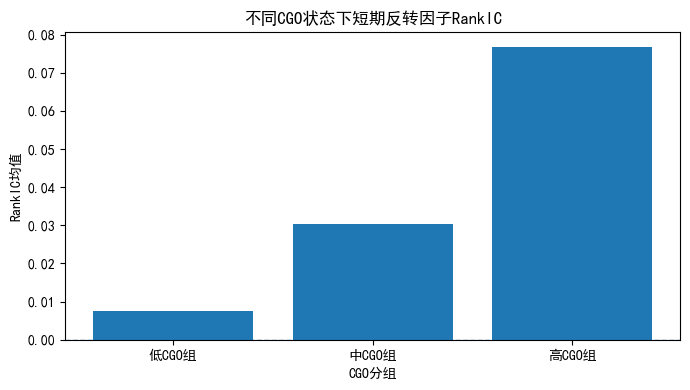

In [21]:
plot_data = cgo_group_ic_summary.copy()

order = ["低CGO组", "中CGO组", "高CGO组"]
plot_data["cgo_group"] = pd.Categorical(plot_data["cgo_group"], categories=order, ordered=True)
plot_data = plot_data.sort_values("cgo_group")

plt.figure(figsize=(7, 4))
plt.bar(plot_data["cgo_group"], plot_data["ic_mean"])
plt.axhline(0, linestyle="--", linewidth=1)
plt.title("不同CGO状态下短期反转因子RankIC")
plt.xlabel("CGO分组")
plt.ylabel("RankIC均值")
plt.tight_layout()
plt.savefig("cgo_group_rev_ic.png", dpi=300, bbox_inches="tight")
plt.show()

## 不同参考点定义下的高低组IC差异

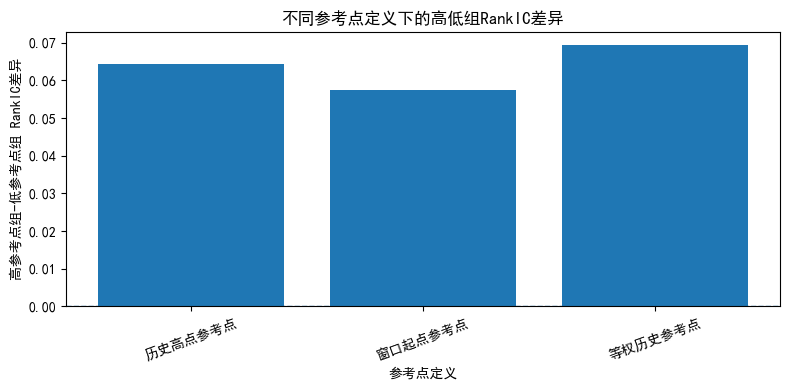

In [22]:
plot_diff = ic_diff_summary.copy()

plt.figure(figsize=(8, 4))
plt.bar(plot_diff["ref_type"], plot_diff["diff_mean"])
plt.axhline(0, linestyle="--", linewidth=1)
plt.title("不同参考点定义下的高低组RankIC差异")
plt.xlabel("参考点定义")
plt.ylabel("高参考点组-低参考点组 RankIC差异")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("ref_point_robust_ic_diff.png", dpi=300, bbox_inches="tight")
plt.show()

参考点状态下的短期反转收益分组检验

In [23]:
ret_group_sample = ic_sample.copy()
#每个月按cgo_ew_12分成三组
ret_group_sample["cgo_group"] = ret_group_sample.groupby("trade_date")["cgo_ew_12"].transform(
    lambda x: pd.qcut(x.rank(method="first"),q=3,labels=["低CGO组", "中CGO组", "高CGO组"])
)

#在每个月、每个CGO组内部，再按短期反转因子rev_1m分成五组
def assign_rev_group(x):
    return pd.qcut(x.rank(method="first"),q=5,labels=["Q1低反转", "Q2", "Q3", "Q4", "Q5高反转"])

ret_group_sample["rev_group"] = ret_group_sample.groupby(
    ["trade_date", "cgo_group"],
    observed=True
)["rev_1m"].transform(assign_rev_group)

ret_group_sample = ret_group_sample.dropna(subset=["cgo_group", "rev_group", "ret_lead1m"])

#计算每个月、每个CGO组、每个反转组的下一月平均收益
monthly_rev_ret = ret_group_sample.groupby(["trade_date", "cgo_group", "rev_group"],observed=True
).agg(
    next_ret_mean=("ret_lead1m", "mean"),
    sample_count=("ts_code", "count")
).reset_index()

#跨月汇总各组收益表现
rev_ret_summary = monthly_rev_ret.groupby(
    ["cgo_group", "rev_group"],
    observed=True
).agg(
    month_num=("trade_date", "nunique"),
    avg_monthly_ret=("next_ret_mean", "mean"),
    std_monthly_ret=("next_ret_mean", "std"),
    pos_month_ratio=("next_ret_mean", lambda x: (x > 0).mean()),
    avg_sample_count=("sample_count", "mean")
).reset_index()

rev_ret_summary["avg_monthly_ret_pct"] = rev_ret_summary["avg_monthly_ret"] * 100
rev_ret_summary["std_monthly_ret_pct"] = rev_ret_summary["std_monthly_ret"] * 100

rev_ret_summary_show = rev_ret_summary.copy()
for col in ["avg_monthly_ret_pct", "std_monthly_ret_pct", "pos_month_ratio", "avg_sample_count"]:
    rev_ret_summary_show[col] = rev_ret_summary_show[col].round(4)

rev_ret_summary_show

,cgo_group,rev_group,month_num,avg_monthly_ret,std_monthly_ret,pos_month_ratio,avg_sample_count,avg_monthly_ret_pct,std_monthly_ret_pct
0,低CGO组,Q1低反转,59,0.015556,0.069108,0.6102,283.6441,1.5556,6.9108
1,低CGO组,Q2,59,0.019779,0.069008,0.5932,283.0847,1.9779,6.9008
2,低CGO组,Q3,59,0.018697,0.069272,0.6271,283.0508,1.8697,6.9272
3,低CGO组,Q4,59,0.018275,0.072594,0.5763,283.0847,1.8275,7.2594
4,低CGO组,Q5高反转,59,0.015560,0.080151,0.5763,283.4576,1.5560,8.0151
5,中CGO组,Q1低反转,59,0.012448,0.061529,0.6271,283.6271,1.2448,6.1529
6,中CGO组,Q2,59,0.020141,0.056912,0.6441,283.0000,2.0141,5.6912
7,中CGO组,Q3,59,0.019914,0.058113,0.6610,283.0000,1.9914,5.8113
8,中CGO组,Q4,59,0.017021,0.061554,0.6441,283.0000,1.7021,6.1554
9,中CGO组,Q5高反转,59,0.015742,0.068079,0.5932,283.4068,1.5742,6.8079


In [24]:
#不同组内的短期反转Q5-Q1收益差
rev_ret_wide = monthly_rev_ret.pivot_table(
    index=["trade_date", "cgo_group"],
    columns="rev_group",
    values="next_ret_mean",
    observed=True
).reset_index()

rev_ret_wide["Q5-Q1"] = rev_ret_wide["Q5高反转"] - rev_ret_wide["Q1低反转"]

q5q1_summary = rev_ret_wide.groupby("cgo_group", observed=True).agg(
    month_num=("trade_date", "nunique"),
    q5q1_mean=("Q5-Q1", "mean"),
    q5q1_std=("Q5-Q1", "std"),
    q5q1_positive_ratio=("Q5-Q1", lambda x: (x > 0).mean()),
    q5q1_min=("Q5-Q1", "min"),
    q5q1_max=("Q5-Q1", "max")
).reset_index()

q5q1_summary["t_stat"] = (
    q5q1_summary["q5q1_mean"] /
    (q5q1_summary["q5q1_std"] / np.sqrt(q5q1_summary["month_num"]))
)

q5q1_summary["q5q1_mean_pct"] = q5q1_summary["q5q1_mean"] * 100
q5q1_summary["q5q1_std_pct"] = q5q1_summary["q5q1_std"] * 100

q5q1_summary_show = q5q1_summary.copy()

for col in ["q5q1_mean_pct", "q5q1_std_pct", "t_stat", "q5q1_positive_ratio", "q5q1_min", "q5q1_max"]:
    q5q1_summary_show[col] = q5q1_summary_show[col].round(4)

q5q1_summary_show[
    ["cgo_group", "month_num", "q5q1_mean_pct", "q5q1_std_pct",
     "t_stat", "q5q1_positive_ratio", "q5q1_min", "q5q1_max"]
]

,cgo_group,month_num,q5q1_mean_pct,q5q1_std_pct,t_stat,q5q1_positive_ratio,q5q1_min,q5q1_max
0,低CGO组,59,0.0004,3.3791,0.0008,0.4746,-0.0740,0.1073
1,中CGO组,59,0.3294,3.1303,0.8083,0.4915,-0.0681,0.0881
2,高CGO组,59,1.3138,4.6727,2.1597,0.6780,-0.1127,0.1130


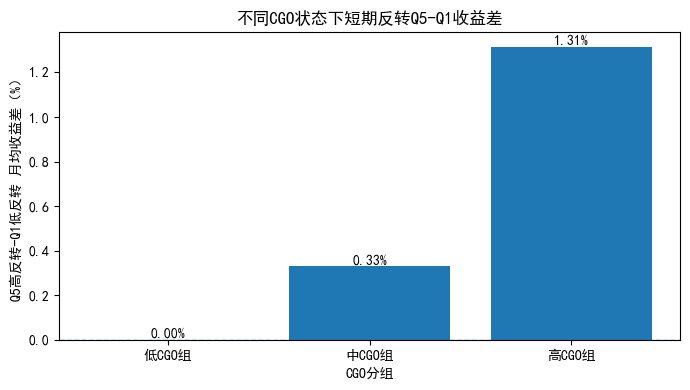

,cgo_group,month_num,q5q1_mean_pct,q5q1_std_pct,t_stat,q5q1_positive_ratio
0,低CGO组,59,0.0004,3.3791,0.0008,0.4746
1,中CGO组,59,0.3294,3.1303,0.8083,0.4915
2,高CGO组,59,1.3138,4.6727,2.1597,0.6780


In [25]:
# 不同CGO状态下短期反转Q5-Q1收益差可视化
plot_q5q1 = q5q1_summary.copy()
order = ["低CGO组", "中CGO组", "高CGO组"]
plot_q5q1["cgo_group"] = pd.Categorical(
    plot_q5q1["cgo_group"],
    categories=order,
    ordered=True
)
plot_q5q1 = plot_q5q1.sort_values("cgo_group")

plt.figure(figsize=(7, 4))
plt.bar(plot_q5q1["cgo_group"], plot_q5q1["q5q1_mean_pct"])
plt.axhline(0, linestyle="--", linewidth=1)
plt.title("不同CGO状态下短期反转Q5-Q1收益差")
plt.xlabel("CGO分组")
plt.ylabel("Q5高反转-Q1低反转 月均收益差（%）")

for i, v in enumerate(plot_q5q1["q5q1_mean_pct"]):
    plt.text(i, v, f"{v:.2f}%", ha="center", va="bottom" if v >= 0 else "top")

plt.tight_layout()
plt.savefig("cgo_group_rev_q5q1_return.png", dpi=300, bbox_inches="tight")
plt.show()

plot_q5q1_show = plot_q5q1[
    ["cgo_group", "month_num", "q5q1_mean_pct", "q5q1_std_pct",
     "t_stat", "q5q1_positive_ratio"]
].copy()

for col in ["q5q1_mean_pct", "q5q1_std_pct", "t_stat", "q5q1_positive_ratio"]:
    plot_q5q1_show[col] = plot_q5q1_show[col].round(4)

plot_q5q1_show

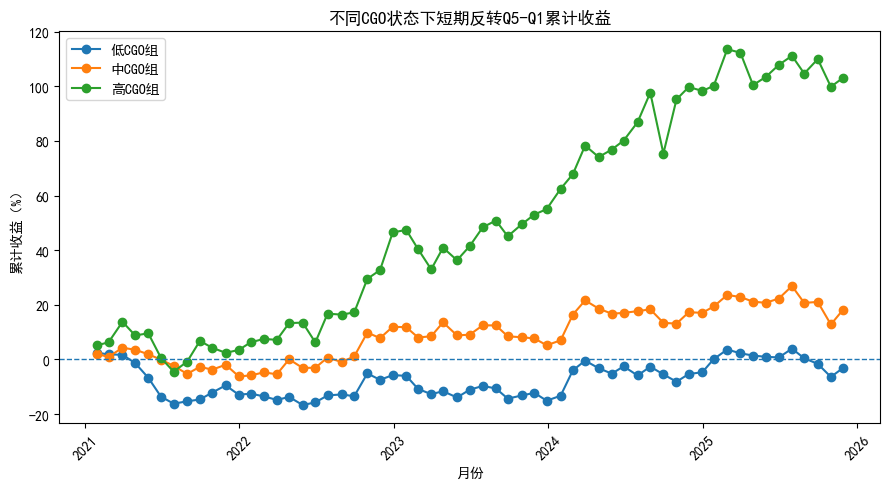

,cgo_group,start_date,end_date,final_cum_return_pct
0,低CGO组,2021-01-29,2025-11-28,-3.1985
1,中CGO组,2021-01-29,2025-11-28,18.0589
2,高CGO组,2021-01-29,2025-11-28,102.9774


In [26]:
# 不同CGO状态下短期反转Q5-Q1累计收益曲线
q5q1_curve = rev_ret_wide[["trade_date", "cgo_group", "Q5-Q1"]].copy()
q5q1_curve = q5q1_curve.sort_values(["cgo_group", "trade_date"])
q5q1_curve["cum_return"] = q5q1_curve.groupby("cgo_group",observed=True)["Q5-Q1"].transform(lambda x: (1 + x).cumprod() - 1)

plt.figure(figsize=(9, 5))
order = ["低CGO组", "中CGO组", "高CGO组"]
for g in order:
    tmp = q5q1_curve[q5q1_curve["cgo_group"] == g]
    plt.plot(
        tmp["trade_date"],
        tmp["cum_return"] * 100,
        marker="o",
        linewidth=1.5,
        label=g
    )

plt.axhline(0, linestyle="--", linewidth=1)
plt.title("不同CGO状态下短期反转Q5-Q1累计收益")
plt.xlabel("月份")
plt.ylabel("累计收益（%）")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig("cgo_group_rev_q5q1_cum_return.png", dpi=300, bbox_inches="tight")
plt.show()

#期末累计收益
q5q1_curve_summary = q5q1_curve.groupby("cgo_group", observed=True).agg(
    start_date=("trade_date", "min"),
    end_date=("trade_date", "max"),
    final_cum_return=("cum_return", "last")
).reset_index()

q5q1_curve_summary["final_cum_return_pct"] = q5q1_curve_summary["final_cum_return"] * 100

q5q1_curve_summary_show = q5q1_curve_summary[
    ["cgo_group", "start_date", "end_date", "final_cum_return_pct"]
].copy()

q5q1_curve_summary_show["final_cum_return_pct"] = q5q1_curve_summary_show["final_cum_return_pct"].round(4)

q5q1_curve_summary_show

# 最终结果

In [27]:
#1.全样本短期反转IC
core_full_ic = pd.DataFrame({
    "结果类型": ["全样本IC"],
    "检验内容": ["短期反转因子rev_1m"],
    "样本/分组": ["全样本"],
    "月份数": [rev_ic_summary.loc[0, "month_num"]],
    "核心指标1": [rev_ic_summary.loc[0, "ic_mean"]],
    "核心指标1名称": ["RankIC均值"],
    "核心指标2": [rev_ic_summary.loc[0, "ic_positive_ratio"]],
    "核心指标2名称": ["IC为正月份占比"],
    "辅助指标": [rev_ic_summary.loc[0, "icir"]],
    "辅助指标名称": ["ICIR"]
})

#2.CGO分组IC结果
core_cgo_ic = cgo_group_ic_summary.copy()
core_cgo_ic["结果类型"] = "CGO分组IC"
core_cgo_ic["检验内容"] = "各CGO组内短期反转因子RankIC"
core_cgo_ic["核心指标1名称"] = "RankIC均值"
core_cgo_ic["核心指标2名称"] = "IC为正月份占比"
core_cgo_ic["辅助指标名称"] = "ICIR"

core_cgo_ic = core_cgo_ic.rename(columns={
    "cgo_group": "样本/分组",
    "month_num": "月份数",
    "ic_mean": "核心指标1",
    "ic_positive_ratio": "核心指标2",
    "icir": "辅助指标"
})

core_cgo_ic = core_cgo_ic[
    ["结果类型", "检验内容", "样本/分组", "月份数",
     "核心指标1", "核心指标1名称", "核心指标2", "核心指标2名称",
     "辅助指标", "辅助指标名称"]
]

#3.不同参考点定义下的稳健性结果
core_ref_diff = ic_diff_summary.copy()
core_ref_diff["结果类型"] = "参考点稳健性"
core_ref_diff["检验内容"] = "高参考点组-低参考点组RankIC差异"
core_ref_diff["样本/分组"] = core_ref_diff["ref_type"]
core_ref_diff["核心指标1"] = core_ref_diff["diff_mean"]
core_ref_diff["核心指标1名称"] = "RankIC差异均值"
core_ref_diff["核心指标2"] = core_ref_diff["diff_positive_ratio"]
core_ref_diff["核心指标2名称"] = "差异为正月份占比"
core_ref_diff["辅助指标"] = core_ref_diff["t_stat"]
core_ref_diff["辅助指标名称"] = "t统计量"

core_ref_diff = core_ref_diff.rename(columns={
    "month_num": "月份数"
})

core_ref_diff = core_ref_diff[
    ["结果类型", "检验内容", "样本/分组", "月份数",
     "核心指标1", "核心指标1名称", "核心指标2", "核心指标2名称",
     "辅助指标", "辅助指标名称"]
]

#4.CGO分组收益检验结果
core_q5q1 = q5q1_summary.copy()
core_q5q1["结果类型"] = "CGO分组收益检验"
core_q5q1["检验内容"] = "各CGO组内短期反转Q5-Q1收益差"
core_q5q1["核心指标1"] = core_q5q1["q5q1_mean"]
core_q5q1["核心指标1名称"] = "Q5-Q1月均收益差"
core_q5q1["核心指标2"] = core_q5q1["q5q1_positive_ratio"]
core_q5q1["核心指标2名称"] = "收益差为正月份占比"
core_q5q1["辅助指标"] = core_q5q1["t_stat"]
core_q5q1["辅助指标名称"] = "t统计量"

core_q5q1 = core_q5q1.rename(columns={
    "cgo_group": "样本/分组",
    "month_num": "月份数"
})

core_q5q1 = core_q5q1[
    ["结果类型", "检验内容", "样本/分组", "月份数",
     "核心指标1", "核心指标1名称", "核心指标2", "核心指标2名称",
     "辅助指标", "辅助指标名称"]
]

#5.合并最终结果表
final_core_result = pd.concat(
    [core_full_ic, core_cgo_ic, core_ref_diff, core_q5q1],
    ignore_index=True
)

#展示版：保留四位小数
final_core_result_show = final_core_result.copy()

for col in ["核心指标1", "核心指标2", "辅助指标"]:
    final_core_result_show[col] = final_core_result_show[col].round(4)

final_core_result_show

,结果类型,检验内容,样本/分组,月份数,核心指标1,核心指标1名称,核心指标2,核心指标2名称,辅助指标,辅助指标名称
0,全样本IC,短期反转因子rev_1m,全样本,59,0.0612,RankIC均值,0.6610,IC为正月份占比,0.4494,ICIR
1,CGO分组IC,各CGO组内短期反转因子RankIC,中CGO组,59,0.0305,RankIC均值,0.5424,IC为正月份占比,0.2291,ICIR
2,CGO分组IC,各CGO组内短期反转因子RankIC,低CGO组,59,0.0076,RankIC均值,0.4915,IC为正月份占比,0.0544,ICIR
3,CGO分组IC,各CGO组内短期反转因子RankIC,高CGO组,59,0.0768,RankIC均值,0.7627,IC为正月份占比,0.5968,ICIR
4,参考点稳健性,高参考点组-低参考点组RankIC差异,历史高点参考点,59,0.0643,RankIC差异均值,0.7627,差异为正月份占比,3.8855,t统计量
5,参考点稳健性,高参考点组-低参考点组RankIC差异,窗口起点参考点,59,0.0574,RankIC差异均值,0.7288,差异为正月份占比,4.1450,t统计量
6,参考点稳健性,高参考点组-低参考点组RankIC差异,等权历史参考点,59,0.0693,RankIC差异均值,0.7288,差异为正月份占比,4.3401,t统计量
7,CGO分组收益检验,各CGO组内短期反转Q5-Q1收益差,低CGO组,59,0.0000,Q5-Q1月均收益差,0.4746,收益差为正月份占比,0.0008,t统计量
8,CGO分组收益检验,各CGO组内短期反转Q5-Q1收益差,中CGO组,59,0.0033,Q5-Q1月均收益差,0.4915,收益差为正月份占比,0.8083,t统计量
9,CGO分组收益检验,各CGO组内短期反转Q5-Q1收益差,高CGO组,59,0.0131,Q5-Q1月均收益差,0.6780,收益差为正月份占比,2.1597,t统计量


以下为原来主题的代码

kmeans聚类

In [17]:
cluster_cols=[f"path_{k}" for k in range(1,12)]
x=path_sample[cluster_cols].copy()
scaler=StandardScaler()
x_scaled=scaler.fit_transform(x)

kmeans=KMeans(n_clusters=5,random_state=42,n_init=20)
path_sample["cluster"]=kmeans.fit_predict(x_scaled)

cluster_count=path_sample["cluster"].value_counts().sort_index()
cluster_ratio=cluster_count/cluster_count.sum()
cluster_summary=pd.DataFrame({"sample_count":cluster_count,"sample_ratio":cluster_ratio})

cluster_summary["sample_ratio_pct"]=cluster_summary["sample_ratio"]*100
print(cluster_summary)

path_sample.to_csv(f"{SAVE_DIR}/path_cluster_sample.csv",index=False,encoding="utf-8-sig")

         sample_count  sample_ratio  sample_ratio_pct
cluster                                              
0               15454      0.061646          6.164586
1               69552      0.277442         27.744226
2               56274      0.224476         22.447645
3                2320      0.009254          0.925446
4              107090      0.427181         42.718098


每条路径到各个聚类中心的距离

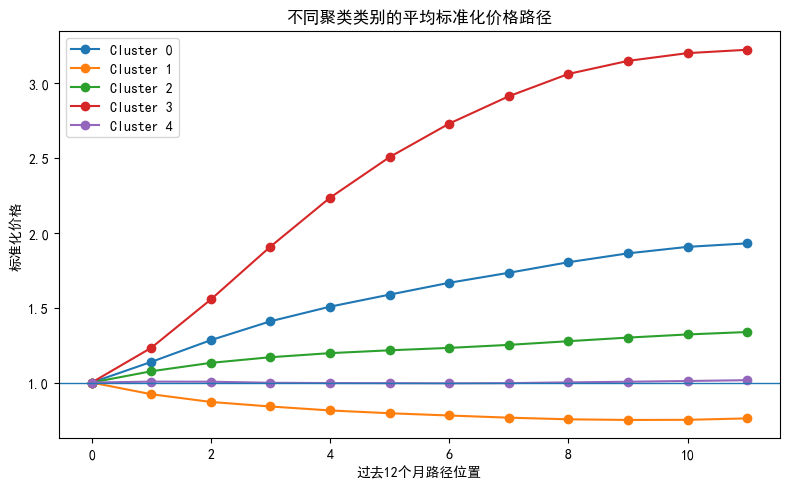

,path_0,path_1,path_2,path_3,path_4,path_5,path_6,path_7,path_8,path_9,path_10,path_11
cluster,,,,,,,,,,,,
0,1.0,1.137964,1.283559,1.409540,1.507299,1.587828,1.666849,1.733639,1.804229,1.863542,1.906847,1.930373
1,1.0,0.922134,0.870255,0.839960,0.813568,0.794831,0.779794,0.765243,0.754359,0.750064,0.750933,0.760497
2,1.0,1.075508,1.131685,1.169307,1.196559,1.215579,1.231656,1.251855,1.276430,1.300541,1.321499,1.337741
3,1.0,1.232225,1.555454,1.908752,2.235499,2.507153,2.730852,2.913454,3.062711,3.149930,3.201778,3.224197
4,1.0,1.006229,1.005595,0.998548,0.996585,0.996080,0.994936,0.996169,1.001130,1.005379,1.010451,1.015853


In [19]:
cluster_path=path_sample.groupby("cluster")[path_cols].mean()
plt.figure(figsize=(8,5))

for c in cluster_path.index:
    plt.plot(
        range(12),
        cluster_path.loc[c].values,
        marker="o",
        label=f"Cluster {c}"
    )

plt.axhline(1,linewidth=1)
plt.title("不同聚类类别的平均标准化价格路径")
plt.xlabel("过去12个月路径位置")
plt.ylabel("标准化价格")
plt.legend()
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/cluster_average_path.png",dpi=300)
plt.show()
cluster_path

命名

In [20]:
cluster_name_map={
    0:"强势上涨型",
    1:"持续下跌型",
    2:"温和上涨型",
    3:"极端上涨型",
    4:"横盘震荡型"
}

path_sample["cluster_name"]=path_sample["cluster"].map(cluster_name_map)

In [21]:
cluster_ret_summary=path_sample.groupby(["cluster","cluster_name"]).agg(
    sample_count=("ts_code","count"),
    stock_count=("ts_code","nunique"),
    next_ret_mean=("ret_lead1m","mean"),
    next_ret_std=("ret_lead1m","std"),
    next_ret_median=("ret_lead1m","median")
).reset_index()

cluster_ret_summary["sample_ratio"]=cluster_ret_summary["sample_count"]/cluster_ret_summary["sample_count"].sum()
cluster_ret_summary["sample_ratio_pct"]=cluster_ret_summary["sample_ratio"]*100
cluster_ret_summary["next_ret_mean_pct"]=cluster_ret_summary["next_ret_mean"]*100
cluster_ret_summary["next_ret_std_pct"]=cluster_ret_summary["next_ret_std"]*100
cluster_ret_summary["next_ret_median_pct"]=cluster_ret_summary["next_ret_median"]*100

cluster_ret_summary=cluster_ret_summary[
    ["cluster","cluster_name","sample_count","stock_count",
     "sample_ratio_pct","next_ret_mean","next_ret_mean_pct",
     "next_ret_std","next_ret_std_pct",
     "next_ret_median","next_ret_median_pct"]
].sort_values("cluster").reset_index(drop=True)

cluster_ret_summary.to_csv(
    f"{SAVE_DIR}/cluster_return_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

cluster_ret_summary

,cluster,cluster_name,sample_count,stock_count,sample_ratio_pct,next_ret_mean,next_ret_mean_pct,next_ret_std,next_ret_std_pct,next_ret_median,next_ret_median_pct
0,0,强势上涨型,15454,3298,6.164586,0.015729,1.572907,0.162688,16.268830,-0.002347,-0.234742
1,1,持续下跌型,69552,4781,27.744226,0.017855,1.785460,0.143472,14.347178,0.001757,0.175747
2,2,温和上涨型,56274,4790,22.447645,0.013715,1.371542,0.144357,14.435719,0.001280,0.127959
3,3,极端上涨型,2320,698,0.925446,0.011156,1.115645,0.187958,18.795805,-0.015734,-1.573398
4,4,横盘震荡型,107090,4825,42.718098,0.011534,1.153364,0.128359,12.835908,0.000000,0.000000


In [22]:
monthly_cluster_ret=path_sample.groupby(["trade_date","cluster","cluster_name"]).agg(next_ret_mean=("ret_lead1m","mean"),sample_count=("ts_code","count")).reset_index()
cluster_ret_monthly_summary=monthly_cluster_ret.groupby(
    ["cluster","cluster_name"]
).agg(
    month_num=("trade_date","nunique"),
    avg_monthly_ret=("next_ret_mean","mean"),
    std_monthly_ret=("next_ret_mean","std"),
    pos_month_ratio=("next_ret_mean",lambda x:(x>0).mean()),
    avg_sample_count=("sample_count","mean")
).reset_index()

cluster_ret_monthly_summary["avg_monthly_ret_pct"]=cluster_ret_monthly_summary["avg_monthly_ret"]*100
cluster_ret_monthly_summary["std_monthly_ret_pct"]=cluster_ret_monthly_summary["std_monthly_ret"]*100
cluster_ret_monthly_summary["pos_month_ratio_pct"]=cluster_ret_monthly_summary["pos_month_ratio"]*100
cluster_ret_monthly_summary=cluster_ret_monthly_summary[
    ["cluster","cluster_name","month_num","avg_sample_count",
     "avg_monthly_ret","avg_monthly_ret_pct",
     "std_monthly_ret","std_monthly_ret_pct",
     "pos_month_ratio","pos_month_ratio_pct"]
].sort_values("cluster").reset_index(drop=True)

cluster_ret_monthly_summary.to_csv(f"{SAVE_DIR}/cluster_return_monthly_summary.csv",index=False,encoding="utf-8-sig")

cluster_ret_monthly_summary

,cluster,cluster_name,month_num,avg_sample_count,avg_monthly_ret,avg_monthly_ret_pct,std_monthly_ret,std_monthly_ret_pct,pos_month_ratio,pos_month_ratio_pct
0,0,强势上涨型,59,261.932203,0.008476,0.847558,0.083249,8.324887,0.508475,50.847458
1,1,持续下跌型,59,1178.847458,0.011622,1.162241,0.066733,6.673338,0.593220,59.322034
2,2,温和上涨型,59,953.796610,0.012670,1.267030,0.063268,6.326756,0.576271,57.627119
3,3,极端上涨型,59,39.322034,0.006802,0.680177,0.112466,11.246643,0.440678,44.067797
4,4,横盘震荡型,59,1815.084746,0.014405,1.440469,0.057758,5.775781,0.627119,62.711864


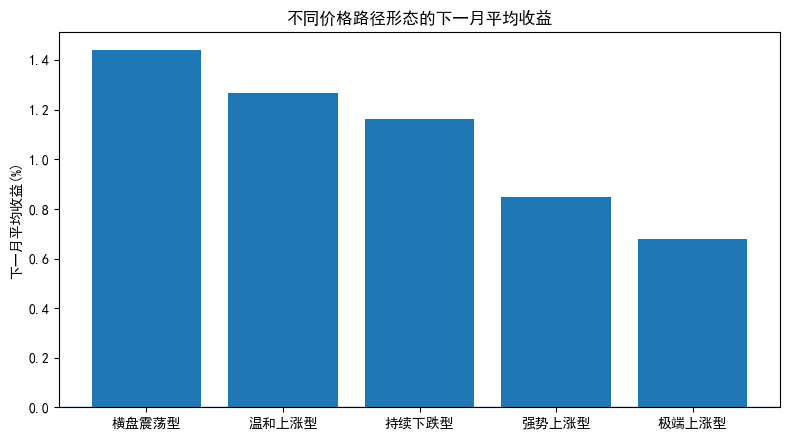

In [23]:
plot_data=cluster_ret_monthly_summary.copy()
plot_data=plot_data.sort_values("avg_monthly_ret_pct",ascending=False)

plt.figure(figsize=(8,4.5))
plt.bar(plot_data["cluster_name"],plot_data["avg_monthly_ret_pct"])
plt.axhline(0,linewidth=1)
plt.title("不同价格路径形态的下一月平均收益")
plt.ylabel("下一月平均收益(%)")
plt.xlabel("")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/cluster_next_return.png",dpi=300)
plt.show()

横盘震荡型收益最高，极端上涨型最低。

和传统动量结论不一样，说明“过去一年涨得特别猛”不一定更好，路径形态能提供新的解释角度

In [24]:
cluster_ret_wide=monthly_cluster_ret.pivot(
    index="trade_date",
    columns="cluster_name",
    values="next_ret_mean"
)

cluster_ret_wide["横盘震荡型-极端上涨型"]=cluster_ret_wide["横盘震荡型"]-cluster_ret_wide["极端上涨型"]

path_spread_summary=pd.DataFrame({
    "指标":["平均收益差","收益差标准差","收益差为正月份占比","最大值","最小值","月份数量"],
    "数值":[
        cluster_ret_wide["横盘震荡型-极端上涨型"].mean(),
        cluster_ret_wide["横盘震荡型-极端上涨型"].std(),
        (cluster_ret_wide["横盘震荡型-极端上涨型"]>0).mean(),
        cluster_ret_wide["横盘震荡型-极端上涨型"].max(),
        cluster_ret_wide["横盘震荡型-极端上涨型"].min(),
        cluster_ret_wide["横盘震荡型-极端上涨型"].count()
    ]
})

path_spread_summary["数值(%)"]=path_spread_summary["数值"]

path_spread_summary.loc[
    path_spread_summary["指标"]!="月份数量",
    "数值(%)"
]=path_spread_summary.loc[
    path_spread_summary["指标"]!="月份数量",
    "数值"
]*100

path_spread_summary.to_csv(
    f"{SAVE_DIR}/path_spread_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

path_spread_summary

,指标,数值,数值(%)
0,平均收益差,0.007603,0.760292
1,收益差标准差,0.080798,8.079760
2,收益差为正月份占比,0.593220,59.322034
3,最大值,0.154710,15.470995
4,最小值,-0.220669,-22.066917
5,月份数量,59.000000,59.000000


In [25]:
compare_rows=[
    {
        "方法":"短期反转",
        "分组方式":"五分位分组",
        "高收益方向":"Q5-Q1",
        "平均收益差(%)":factor_result_pct.loc[factor_result_pct["factor_name"]=="短期反转","Q5_Q1_mean"].iloc[0],
        "收益差为正月份占比(%)":factor_result_pct.loc[factor_result_pct["factor_name"]=="短期反转","Q5_Q1_pos_ratio"].iloc[0],
        "说明":"当月跌幅较大股票相对当月涨幅较大股票"
    },
    {
        "方法":"中期动量",
        "分组方式":"五分位分组",
        "高收益方向":"Q5-Q1",
        "平均收益差(%)":factor_result_pct.loc[factor_result_pct["factor_name"]=="中期动量","Q5_Q1_mean"].iloc[0],
        "收益差为正月份占比(%)":factor_result_pct.loc[factor_result_pct["factor_name"]=="中期动量","Q5_Q1_pos_ratio"].iloc[0],
        "说明":"过去12个月高收益股票相对低收益股票"
    },
    {
        "方法":"波动率",
        "分组方式":"五分位分组",
        "高收益方向":"Q5-Q1",
        "平均收益差(%)":factor_result_pct.loc[factor_result_pct["factor_name"]=="波动率","Q5_Q1_mean"].iloc[0],
        "收益差为正月份占比(%)":factor_result_pct.loc[factor_result_pct["factor_name"]=="波动率","Q5_Q1_pos_ratio"].iloc[0],
        "说明":"过去12个月高波动股票相对低波动股票"
    },
    {
        "方法":"价格路径聚类",
        "分组方式":"KMeans聚类",
        "高收益方向":"横盘震荡型-极端上涨型",
        "平均收益差(%)":path_spread_summary.loc[path_spread_summary["指标"]=="平均收益差","数值(%)"].iloc[0],
        "收益差为正月份占比(%)":path_spread_summary.loc[path_spread_summary["指标"]=="收益差为正月份占比","数值(%)"].iloc[0],
        "说明":"横盘震荡型股票相对极端上涨型股票"
    }
]

method_compare=pd.DataFrame(compare_rows)

method_compare.to_csv(
    f"{SAVE_DIR}/method_compare_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

method_compare

,方法,分组方式,高收益方向,平均收益差(%),收益差为正月份占比(%),说明
0,短期反转,五分位分组,Q5-Q1,0.920065,54.237288,当月跌幅较大股票相对当月涨幅较大股票
1,中期动量,五分位分组,Q5-Q1,-0.865626,42.372881,过去12个月高收益股票相对低收益股票
2,波动率,五分位分组,Q5-Q1,-0.569390,42.372881,过去12个月高波动股票相对低波动股票
3,价格路径聚类,KMeans聚类,横盘震荡型-极端上涨型,0.760292,59.322034,横盘震荡型股票相对极端上涨型股票


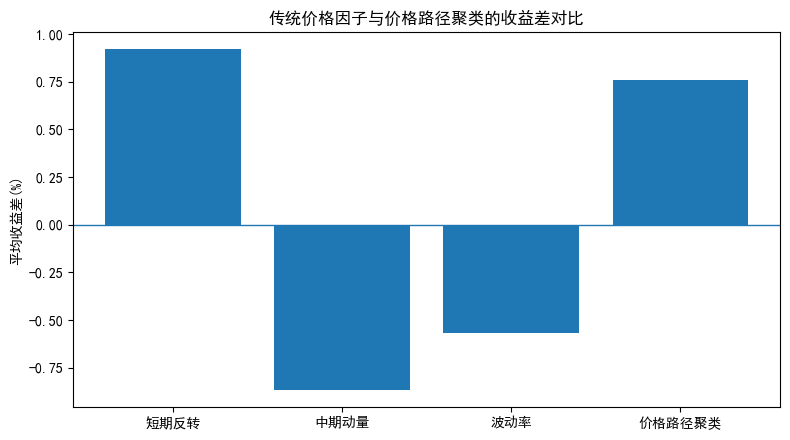

,方法,分组方式,高收益方向,平均收益差(%),收益差为正月份占比(%),说明
0,短期反转,五分位分组,Q5-Q1,0.920065,54.237288,当月跌幅较大股票相对当月涨幅较大股票
1,中期动量,五分位分组,Q5-Q1,-0.865626,42.372881,过去12个月高收益股票相对低收益股票
2,波动率,五分位分组,Q5-Q1,-0.569390,42.372881,过去12个月高波动股票相对低波动股票
3,价格路径聚类,KMeans聚类,横盘震荡型-极端上涨型,0.760292,59.322034,横盘震荡型股票相对极端上涨型股票


In [26]:
plot_compare=method_compare.copy()

plt.figure(figsize=(8,4.5))
plt.bar(plot_compare["方法"],plot_compare["平均收益差(%)"])
plt.axhline(0,linewidth=1)
plt.title("传统价格因子与价格路径聚类的收益差对比")
plt.ylabel("平均收益差(%)")
plt.xlabel("")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/method_compare_return_spread.png",dpi=300)
plt.show()

method_compare

选择k值

In [28]:
from sklearn.metrics import silhouette_score

k_result=[]
sample_n=min(30000,len(x_scaled))
sample_idx=np.random.RandomState(42).choice(len(x_scaled),sample_n,replace=False)
x_sample=x_scaled[sample_idx]

for k in range(3,9):
    km=KMeans(n_clusters=k,random_state=42,n_init=20)
    label=km.fit_predict(x_scaled)
    
    sample_label=label[sample_idx]
    sil=silhouette_score(x_sample,sample_label)
    
    k_result.append({
        "k":k,
        "inertia":km.inertia_,
        "silhouette":sil
    })
k_result=pd.DataFrame(k_result)
k_result.to_csv(f"{SAVE_DIR}/kmeans_k_selection.csv",index=False,encoding="utf-8-sig")

k_result

,k,inertia,silhouette
0,3,1.412971e+06,0.311242
1,4,1.232007e+06,0.254964
2,5,1.135190e+06,0.211193
3,6,1.059206e+06,0.202022
4,7,9.950628e+05,0.194346
5,8,9.421911e+05,0.171691


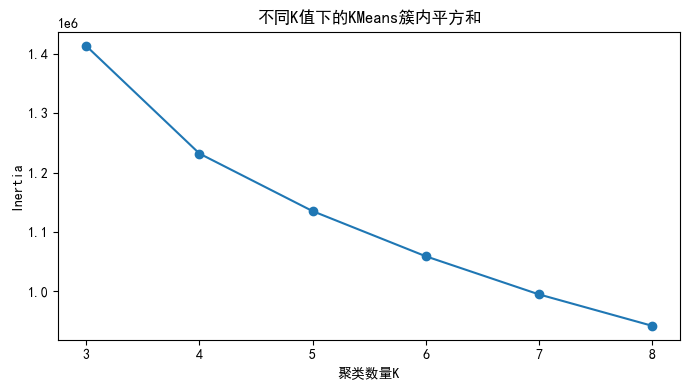

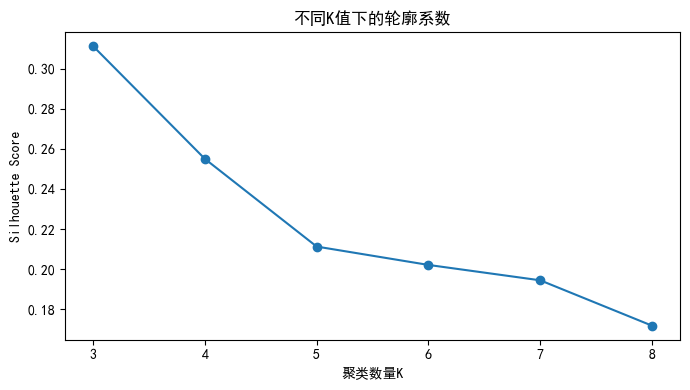

In [29]:
plt.figure(figsize=(7,4))
plt.plot(k_result["k"],k_result["inertia"],marker="o")
plt.title("不同K值下的KMeans簇内平方和")
plt.xlabel("聚类数量K")
plt.ylabel("Inertia")
plt.xticks(k_result["k"])
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/kmeans_inertia.png",dpi=300)
plt.show()

plt.figure(figsize=(7,4))
plt.plot(k_result["k"],k_result["silhouette"],marker="o")
plt.title("不同K值下的轮廓系数")
plt.xlabel("聚类数量K")
plt.ylabel("Silhouette Score")
plt.xticks(k_result["k"])
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/kmeans_silhouette.png",dpi=300)
plt.show()

选k

In [27]:
dist_matrix=kmeans.transform(x_scaled)

dist_cols=[f"dist_cluster_{i}" for i in range(kmeans.n_clusters)]
dist_df=pd.DataFrame(dist_matrix,columns=dist_cols,index=path_sample.index)
path_sample=pd.concat([path_sample,dist_df],axis=1)
path_sample["cluster_dist"]=path_sample[dist_cols].min(axis=1)
path_sample["nearest_cluster"]=path_sample[dist_cols].idxmin(axis=1).str.replace("dist_cluster_","").astype(int)

print("聚类结果是否等于最近中心:",(path_sample["cluster"]==path_sample["nearest_cluster"]).mean())

dist_summary=path_sample.groupby(["cluster","cluster_name"]).agg(
    sample_count=("ts_code","count"),
    avg_dist=("cluster_dist","mean"),
    median_dist=("cluster_dist","median"),
    max_dist=("cluster_dist","max")
).reset_index()

dist_summary.to_csv(
    f"{SAVE_DIR}/cluster_distance_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

dist_summary

聚类结果是否等于最近中心: 1.0


,cluster,cluster_name,sample_count,avg_dist,median_dist,max_dist
0,0,强势上涨型,15454,3.722784,3.275027,23.081379
1,1,持续下跌型,69552,1.331002,1.233755,7.558895
2,2,温和上涨型,56274,1.994101,1.792785,13.345305
3,3,极端上涨型,2320,8.413243,6.909451,80.334833
4,4,横盘震荡型,107090,1.352498,1.248943,9.810478


In [30]:
kmeans3=KMeans(n_clusters=3,random_state=42,n_init=20)
path_sample["cluster_k3"]=kmeans3.fit_predict(x_scaled)

cluster3_count=path_sample["cluster_k3"].value_counts().sort_index()
cluster3_ratio=cluster3_count/cluster3_count.sum()

cluster3_summary=pd.DataFrame({
    "sample_count":cluster3_count,
    "sample_ratio_pct":cluster3_ratio*100
})

cluster3_path=path_sample.groupby("cluster_k3")[path_cols].mean()

print("K=3聚类样本分布:")
print(cluster3_summary)

cluster3_path

K=3聚类样本分布:
            sample_count  sample_ratio_pct
cluster_k3                                
0                  99317         39.617456
1                 139302         55.567434
2                  12071          4.815110


,path_0,path_1,path_2,path_3,path_4,path_5,path_6,path_7,path_8,path_9,path_10,path_11
cluster_k3,,,,,,,,,,,,
0,1.0,1.060471,1.104553,1.132835,1.154895,1.170910,1.184593,1.201695,1.223474,1.243791,1.261830,1.274954
1,1.0,0.958170,0.927376,0.905629,0.889064,0.877792,0.868243,0.859937,0.855101,0.853678,0.855312,0.862413
2,1.0,1.165066,1.363614,1.549392,1.704569,1.834412,1.954359,2.051362,2.142899,2.210218,2.256054,2.279309


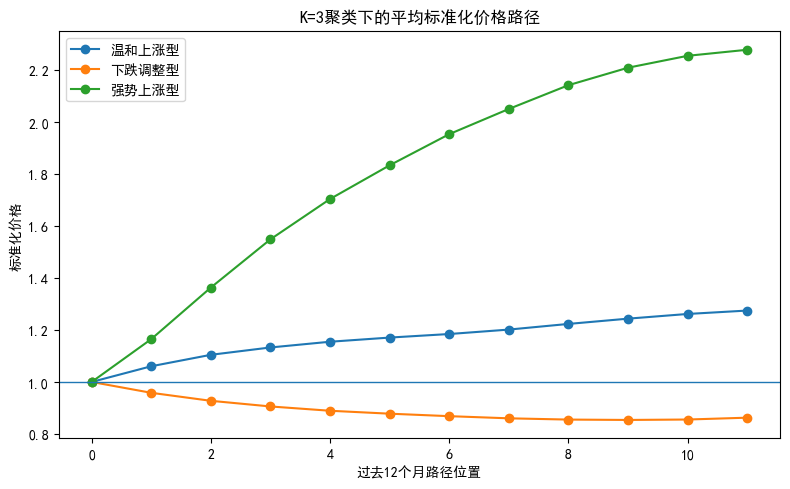

In [31]:
cluster3_name_map={
    0:"温和上涨型",
    1:"下跌调整型",
    2:"强势上涨型"
}

path_sample["cluster3_name"]=path_sample["cluster_k3"].map(cluster3_name_map)

plt.figure(figsize=(8,5))

for c in cluster3_path.index:
    plt.plot(
        range(12),
        cluster3_path.loc[c].values,
        marker="o",
        label=cluster3_name_map[c]
    )

plt.axhline(1,linewidth=1)
plt.title("K=3聚类下的平均标准化价格路径")
plt.xlabel("过去12个月路径位置")
plt.ylabel("标准化价格")
plt.legend()
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/cluster3_average_path.png",dpi=300)
plt.show()

In [32]:
monthly_cluster3_ret=path_sample.groupby(
    ["trade_date","cluster_k3","cluster3_name"]
).agg(
    next_ret_mean=("ret_lead1m","mean"),
    sample_count=("ts_code","count")
).reset_index()

cluster3_ret_summary=monthly_cluster3_ret.groupby(
    ["cluster_k3","cluster3_name"]
).agg(
    month_num=("trade_date","nunique"),
    avg_sample_count=("sample_count","mean"),
    avg_monthly_ret=("next_ret_mean","mean"),
    std_monthly_ret=("next_ret_mean","std"),
    pos_month_ratio=("next_ret_mean",lambda x:(x>0).mean())
).reset_index()

cluster3_ret_summary["avg_monthly_ret_pct"]=cluster3_ret_summary["avg_monthly_ret"]*100
cluster3_ret_summary["std_monthly_ret_pct"]=cluster3_ret_summary["std_monthly_ret"]*100
cluster3_ret_summary["pos_month_ratio_pct"]=cluster3_ret_summary["pos_month_ratio"]*100

cluster3_ret_summary=cluster3_ret_summary[
    ["cluster_k3","cluster3_name","month_num","avg_sample_count",
     "avg_monthly_ret","avg_monthly_ret_pct",
     "std_monthly_ret","std_monthly_ret_pct",
     "pos_month_ratio","pos_month_ratio_pct"]
].sort_values("cluster_k3").reset_index(drop=True)

cluster3_ret_summary.to_csv(
    f"{SAVE_DIR}/cluster3_return_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

cluster3_ret_summary

,cluster_k3,cluster3_name,month_num,avg_sample_count,avg_monthly_ret,avg_monthly_ret_pct,std_monthly_ret,std_monthly_ret_pct,pos_month_ratio,pos_month_ratio_pct
0,0,温和上涨型,59,1683.338983,0.012916,1.291586,0.061595,6.159470,0.593220,59.322034
1,1,下跌调整型,59,2361.050847,0.013539,1.353866,0.061788,6.178778,0.610169,61.016949
2,2,强势上涨型,59,204.593220,0.008924,0.892432,0.091102,9.110244,0.474576,47.457627


In [33]:
cluster3_ret_wide=monthly_cluster3_ret.pivot(
    index="trade_date",
    columns="cluster3_name",
    values="next_ret_mean"
)

cluster3_ret_wide["下跌调整型-强势上涨型"]=cluster3_ret_wide["下跌调整型"]-cluster3_ret_wide["强势上涨型"]

cluster3_spread_summary=pd.DataFrame({
    "指标":["平均收益差","收益差标准差","收益差为正月份占比","最大值","最小值","月份数量"],
    "数值":[
        cluster3_ret_wide["下跌调整型-强势上涨型"].mean(),
        cluster3_ret_wide["下跌调整型-强势上涨型"].std(),
        (cluster3_ret_wide["下跌调整型-强势上涨型"]>0).mean(),
        cluster3_ret_wide["下跌调整型-强势上涨型"].max(),
        cluster3_ret_wide["下跌调整型-强势上涨型"].min(),
        cluster3_ret_wide["下跌调整型-强势上涨型"].count()
    ]
})

cluster3_spread_summary["数值(%)"]=cluster3_spread_summary["数值"]

cluster3_spread_summary.loc[
    cluster3_spread_summary["指标"]!="月份数量",
    "数值(%)"
]=cluster3_spread_summary.loc[
    cluster3_spread_summary["指标"]!="月份数量",
    "数值"
]*100

cluster3_spread_summary.to_csv(
    f"{SAVE_DIR}/cluster3_spread_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

cluster3_spread_summary

,指标,数值,数值(%)
0,平均收益差,0.004614,0.461433
1,收益差标准差,0.057113,5.711342
2,收益差为正月份占比,0.525424,52.542373
3,最大值,0.124549,12.454934
4,最小值,-0.188190,-18.819036
5,月份数量,59.000000,59.000000


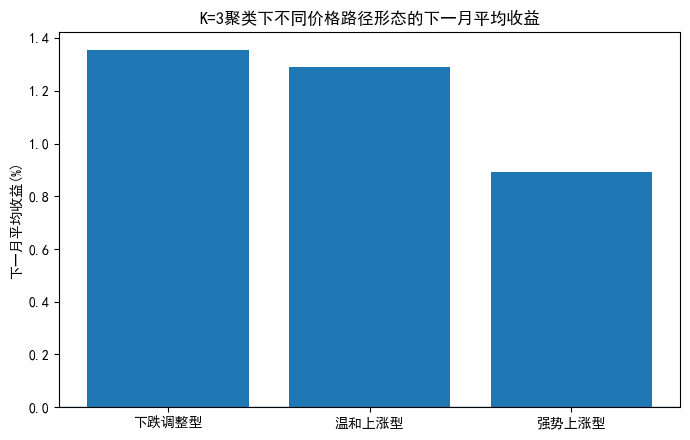

,cluster3_name,avg_monthly_ret_pct,pos_month_ratio_pct
1,下跌调整型,1.353866,61.016949
0,温和上涨型,1.291586,59.322034
2,强势上涨型,0.892432,47.457627


In [34]:
plot_cluster3=cluster3_ret_summary.sort_values("avg_monthly_ret_pct",ascending=False)

plt.figure(figsize=(7,4.5))
plt.bar(plot_cluster3["cluster3_name"],plot_cluster3["avg_monthly_ret_pct"])
plt.axhline(0,linewidth=1)
plt.title("K=3聚类下不同价格路径形态的下一月平均收益")
plt.ylabel("下一月平均收益(%)")
plt.xlabel("")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/cluster3_next_return.png",dpi=300)
plt.show()

plot_cluster3[["cluster3_name","avg_monthly_ret_pct","pos_month_ratio_pct"]]

In [35]:
cluster_factor=path_sample.merge(
    factor_sample[["ts_code","trade_date","reversal_1m","momentum_12m","volatility_12m"]],
    on=["ts_code","trade_date"],
    how="left"
)

cluster3_factor_summary=cluster_factor.groupby(
    ["cluster_k3","cluster3_name"]
).agg(
    sample_count=("ts_code","count"),
    ret_1m_mean=("ret","mean"),
    reversal_1m_mean=("reversal_1m","mean"),
    momentum_12m_mean=("momentum_12m","mean"),
    volatility_12m_mean=("volatility_12m","mean"),
    next_ret_mean=("ret_lead1m","mean")
).reset_index()

pct_cols=[
    "ret_1m_mean",
    "reversal_1m_mean",
    "momentum_12m_mean",
    "volatility_12m_mean",
    "next_ret_mean"
]

for col in pct_cols:
    cluster3_factor_summary[col+"_pct"]=cluster3_factor_summary[col]*100

cluster3_factor_summary=cluster3_factor_summary[
    ["cluster_k3","cluster3_name","sample_count",
     "ret_1m_mean_pct","reversal_1m_mean_pct",
     "momentum_12m_mean_pct","volatility_12m_mean_pct",
     "next_ret_mean_pct"]
].sort_values("cluster_k3").reset_index(drop=True)

cluster3_factor_summary.to_csv(
    f"{SAVE_DIR}/cluster3_factor_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

cluster3_factor_summary

,cluster_k3,cluster3_name,sample_count,ret_1m_mean_pct,reversal_1m_mean_pct,momentum_12m_mean_pct,volatility_12m_mean_pct,next_ret_mean_pct
0,0,温和上涨型,99317,1.360817,-1.360817,26.760605,12.874549,1.245887
1,1,下跌调整型,139302,1.159420,-1.159420,-12.189659,11.200162,1.493100
2,2,强势上涨型,12071,1.671351,-1.671351,129.974996,24.115908,1.660553


In [36]:
cluster3_factor_monthly=cluster_factor.groupby(
    ["trade_date","cluster_k3","cluster3_name"]
).agg(
    ret_1m_mean=("ret","mean"),
    reversal_1m_mean=("reversal_1m","mean"),
    momentum_12m_mean=("momentum_12m","mean"),
    volatility_12m_mean=("volatility_12m","mean"),
    next_ret_mean=("ret_lead1m","mean"),
    sample_count=("ts_code","count")
).reset_index()

cluster3_factor_monthly_summary=cluster3_factor_monthly.groupby(
    ["cluster_k3","cluster3_name"]
).agg(
    month_num=("trade_date","nunique"),
    avg_sample_count=("sample_count","mean"),
    ret_1m_mean=("ret_1m_mean","mean"),
    reversal_1m_mean=("reversal_1m_mean","mean"),
    momentum_12m_mean=("momentum_12m_mean","mean"),
    volatility_12m_mean=("volatility_12m_mean","mean"),
    next_ret_mean=("next_ret_mean","mean")
).reset_index()

pct_cols=[
    "ret_1m_mean",
    "reversal_1m_mean",
    "momentum_12m_mean",
    "volatility_12m_mean",
    "next_ret_mean"
]

for col in pct_cols:
    cluster3_factor_monthly_summary[col+"_pct"]=cluster3_factor_monthly_summary[col]*100

cluster3_factor_monthly_summary=cluster3_factor_monthly_summary[
    ["cluster_k3","cluster3_name","month_num","avg_sample_count",
     "ret_1m_mean_pct","reversal_1m_mean_pct",
     "momentum_12m_mean_pct","volatility_12m_mean_pct",
     "next_ret_mean_pct"]
].sort_values("cluster_k3").reset_index(drop=True)

cluster3_factor_monthly_summary.to_csv(
    f"{SAVE_DIR}/cluster3_factor_monthly_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

cluster3_factor_monthly_summary

,cluster_k3,cluster3_name,month_num,avg_sample_count,ret_1m_mean_pct,reversal_1m_mean_pct,momentum_12m_mean_pct,volatility_12m_mean_pct,next_ret_mean_pct
0,0,温和上涨型,59,1683.338983,1.454946,-1.454946,26.778244,13.259570,1.291586
1,1,下跌调整型,59,2361.050847,0.890336,-0.890336,-11.244020,10.981767,1.353866
2,2,强势上涨型,59,204.593220,1.683200,-1.683200,129.523354,26.348928,0.892432


In [37]:
dist3_matrix=kmeans3.transform(x_scaled)

dist3_cols=[f"dist_k3_cluster_{i}" for i in range(kmeans3.n_clusters)]
dist3_df=pd.DataFrame(dist3_matrix,columns=dist3_cols,index=path_sample.index)

path_sample=pd.concat([path_sample,dist3_df],axis=1)

path_sample["cluster3_dist"]=path_sample[dist3_cols].min(axis=1)
path_sample["nearest_cluster_k3"]=path_sample[dist3_cols].idxmin(axis=1).str.replace("dist_k3_cluster_","").astype(int)

print("聚类结果是否等于最近中心:")
print((path_sample["cluster_k3"]==path_sample["nearest_cluster_k3"]).mean())

cluster3_dist_summary=path_sample.groupby(
    ["cluster_k3","cluster3_name"]
).agg(
    sample_count=("ts_code","count"),
    avg_dist=("cluster3_dist","mean"),
    median_dist=("cluster3_dist","median"),
    max_dist=("cluster3_dist","max")
).reset_index()

cluster3_dist_summary.to_csv(
    f"{SAVE_DIR}/cluster3_distance_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

cluster3_dist_summary

聚类结果是否等于最近中心:
1.0


,cluster_k3,cluster3_name,sample_count,avg_dist,median_dist,max_dist
0,0,温和上涨型,99317,2.039438,1.777175,15.274828
1,1,下跌调整型,139302,1.496203,1.411413,9.965541
2,2,强势上涨型,12071,5.453060,4.321675,85.982010


主结果汇总

In [38]:
main_result_rows=[
    {
        "模块":"传统因子基准",
        "方法":"短期反转",
        "核心比较":"Q5-Q1",
        "平均收益差(%)":factor_result_pct.loc[factor_result_pct["factor_name"]=="短期反转","Q5_Q1_mean"].iloc[0],
        "收益差为正月份占比(%)":factor_result_pct.loc[factor_result_pct["factor_name"]=="短期反转","Q5_Q1_pos_ratio"].iloc[0],
        "备注":"当月跌幅较大股票相对当月涨幅较大股票"
    },
    {
        "模块":"传统因子基准",
        "方法":"中期动量",
        "核心比较":"Q5-Q1",
        "平均收益差(%)":factor_result_pct.loc[factor_result_pct["factor_name"]=="中期动量","Q5_Q1_mean"].iloc[0],
        "收益差为正月份占比(%)":factor_result_pct.loc[factor_result_pct["factor_name"]=="中期动量","Q5_Q1_pos_ratio"].iloc[0],
        "备注":"过去12个月高收益股票相对低收益股票"
    },
    {
        "模块":"传统因子基准",
        "方法":"波动率",
        "核心比较":"Q5-Q1",
        "平均收益差(%)":factor_result_pct.loc[factor_result_pct["factor_name"]=="波动率","Q5_Q1_mean"].iloc[0],
        "收益差为正月份占比(%)":factor_result_pct.loc[factor_result_pct["factor_name"]=="波动率","Q5_Q1_pos_ratio"].iloc[0],
        "备注":"过去12个月高波动股票相对低波动股票"
    },
    {
        "模块":"路径聚类主分析",
        "方法":"K=3路径聚类",
        "核心比较":"下跌调整型-强势上涨型",
        "平均收益差(%)":cluster3_spread_summary.loc[cluster3_spread_summary["指标"]=="平均收益差","数值(%)"].iloc[0],
        "收益差为正月份占比(%)":cluster3_spread_summary.loc[cluster3_spread_summary["指标"]=="收益差为正月份占比","数值(%)"].iloc[0],
        "备注":"粗粒度路径形态划分"
    },
    {
        "模块":"路径聚类细分分析",
        "方法":"K=5路径聚类",
        "核心比较":"横盘震荡型-极端上涨型",
        "平均收益差(%)":path_spread_summary.loc[path_spread_summary["指标"]=="平均收益差","数值(%)"].iloc[0],
        "收益差为正月份占比(%)":path_spread_summary.loc[path_spread_summary["指标"]=="收益差为正月份占比","数值(%)"].iloc[0],
        "备注":"细分价格路径形态"
    }
]

main_result_summary=pd.DataFrame(main_result_rows)

main_result_summary.to_csv(
    f"{SAVE_DIR}/main_result_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

main_result_summary

,模块,方法,核心比较,平均收益差(%),收益差为正月份占比(%),备注
0,传统因子基准,短期反转,Q5-Q1,0.920065,54.237288,当月跌幅较大股票相对当月涨幅较大股票
1,传统因子基准,中期动量,Q5-Q1,-0.865626,42.372881,过去12个月高收益股票相对低收益股票
2,传统因子基准,波动率,Q5-Q1,-0.569390,42.372881,过去12个月高波动股票相对低波动股票
3,路径聚类主分析,K=3路径聚类,下跌调整型-强势上涨型,0.461433,52.542373,粗粒度路径形态划分
4,路径聚类细分分析,K=5路径聚类,横盘震荡型-极端上涨型,0.760292,59.322034,细分价格路径形态


k3 vs k5

In [40]:
k3_k5_ratio=pd.crosstab(
    path_sample["cluster3_name"],
    path_sample["cluster_name"],
    normalize="index"
)*100

k3_k5_count=pd.crosstab(
    path_sample["cluster3_name"],
    path_sample["cluster_name"]
)

k3_k5_ratio.to_csv(
    f"{SAVE_DIR}/k3_k5_cluster_ratio.csv",
    encoding="utf-8-sig"
)

k3_k5_count.to_csv(
    f"{SAVE_DIR}/k3_k5_cluster_count.csv",
    encoding="utf-8-sig"
)

k3_k5_ratio

cluster_name,强势上涨型,持续下跌型,极端上涨型,横盘震荡型,温和上涨型
cluster3_name,,,,,
下跌调整型,0.000000,49.928931,0.000000,50.071069,0.000000
强势上涨型,80.780383,0.000000,19.219617,0.000000,0.000000
温和上涨型,5.742219,0.000000,0.000000,37.596786,56.660995


矩阵对应着看

比如

K=3中的强势上涨型：

80.78%进入K=5的强势上涨型；
19.22%进入K=5的极端上涨型。